In [1]:
import tensorly as tl

tl.get_backend()

'cupy'

In [2]:
from moabb.paradigms import P300
from moabb.datasets import *

tmin = 0
tmax=0.8
fmin=0.5
fmax = 16
sfreq = 32

paradigm = P300(resample=sfreq, tmin=tmin, tmax=tmax, fmin=fmin, fmax=fmax)
dataset = BNCI2014_009()
epochs, labels, meta = paradigm.get_data(dataset=dataset, 
                                         subjects=[1],
                                         return_epochs=True)
idc = meta['session'] == meta['session'][0]
epochs = epochs[idc]
labels = labels[idc]
meta = meta[idc]

<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.pick_types is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.pick_channels_regexp is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.channel_type is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
/usr/local/lib/python3.10/dist-packages/moabb/pipelines/__init__.py:26: ModuleNotFoundError: Tensorflow is not installed. You won't be able to use these MOABB pipelines if you attempt to do so.
  warn(


To use the get_shape_from_baseconcar, InputShapeSetterEEG, BraindecodeDatasetLoaderyou need to install `braindecode`.`pip install braindecode` or Please refer to `https://braindecode.org`.
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
1728 matching events found
No baseline correction applied


/usr/local/lib/python3.10/dist-packages/moabb/paradigms/base.py:354: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  X = mne.concatenate_epochs(X)


In [3]:
epochs

Number of events,576
Events,NonTarget: 480Target: 96
Time range,0.000 – 0.781 s
Baseline,off


In [4]:
meta

,subject,session,run
0,1,0,0
1,1,0,0
2,1,0,0
3,1,0,0
4,1,0,0
...,...,...,...
571,1,0,0
572,1,0,0
573,1,0,0
574,1,0,0


In [5]:
from hoda.tensorize import hankel_tensor
X = epochs.get_data()
y = labels
print(X.shape)
X = hankel_tensor(X)
X.shape

(576, 16, 26)


/tmp/ipykernel_3762/2316430803.py:2: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  X = epochs.get_data()


(576, 16, 14, 13)

In [6]:
from hoda.hoda import HODA
import warnings



hoda = HODA(
    rank=10,
    max_iter=1024,
    tol=1e-16,
    init ='mlsvd',
    shrinkage='lw',
    toeplitz=(1,2),
    obj='rt',
    solver='lobpcg',
    taper=False,
    extra_train_info=False,
    verbose=True,  
)




hoda.fit(X,y)

Fitting discriminative Tucker model of rank (10, 10, 10)...


  0%|          | 0/1024 [00:00<?, ?it/s]

HODA(init='mlsvd', max_iter=1024, rank=10, solver='lobpcg', toeplitz=(1, 2),
     tol=1e-16, verbose=True)

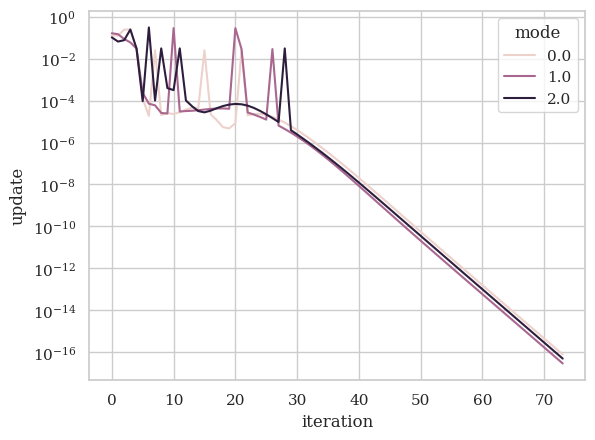

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.lineplot(data=hoda.train_info_.astype(float), x='iteration', y='update', hue='mode')
plt.yscale('log')
plt.show()


In [8]:
hoda.train_info_

,iteration,mode,update,shrinkage,objective
0,0.0,0.0,1.283621e-01,0.000264,5.139672e+08
1,0.0,1.0,1.627184e-01,0.003500,1.293863e+10
2,0.0,2.0,1.034814e-01,0.002941,3.511050e+09
3,1.0,0.0,1.251518e-01,0.000329,8.213393e+08
4,1.0,1.0,1.465137e-01,0.004192,2.302969e+09
...,...,...,...,...,...
217,72.0,1.0,5.226866e-17,0.003687,3.094452e+09
218,72.0,2.0,8.910419e-17,0.003351,3.302591e+09
219,73.0,0.0,7.800235e-17,0.000326,7.835618e+08
220,73.0,1.0,2.909818e-17,0.003687,3.094452e+09


<Axes: xlabel='iteration', ylabel='objective'>

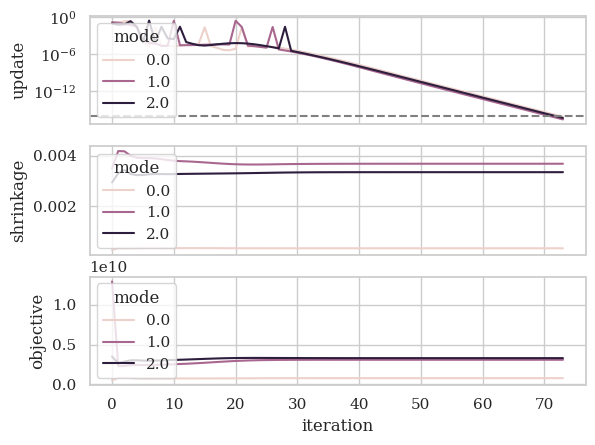

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
fig, axs = plt.subplots(3,1, sharex=True)
sns.lineplot(data=hoda.train_info_.astype(float), x='iteration', y='update',hue='mode', ax=axs[0])
axs[0].axhline(hoda.tol, color='grey', linestyle='--')
axs[0].set_yscale('log')
sns.lineplot(data=hoda.train_info_.astype(float), x='iteration', y='shrinkage',hue='mode', ax=axs[1])
sns.lineplot(data=hoda.train_info_.astype(float), x='iteration', y='objective',hue='mode', ax=axs[2])


In [11]:
if hoda.extra_train_info:
    fig, axs = plt.subplots(5,1, sharex=True)
    sns.lineplot(data=hoda.train_info_.astype(float), x='iteration', y='F_tr', hue='mode', ax=axs[0])
    sns.lineplot(data=hoda.train_info_.astype(float), x='iteration', y='F_rt', hue='mode', ax=axs[1])
    sns.lineplot(data=hoda.train_info_.astype(float), x='iteration', y='mse', hue='mode', ax=axs[2])
    #axs[2].set(yscale="log")
    #axs[2].set_ylim([0,None])
    sns.lineplot(data=hoda.train_info_.astype(float), x='iteration', y='log_like', hue='mode', ax=axs[3])
    sns.lineplot(data=hoda.train_info_.astype(float), x='iteration', y='bic', hue='mode', ax=axs[4])
    sns.lineplot(data=hoda.train_info_.astype(float), x='iteration', y='aic', hue='mode', ax=axs[4]) 
    sns.lineplot(data=hoda.train_info_.astype(float), x='iteration', y='aicc', hue='mode', ax=axs[4])



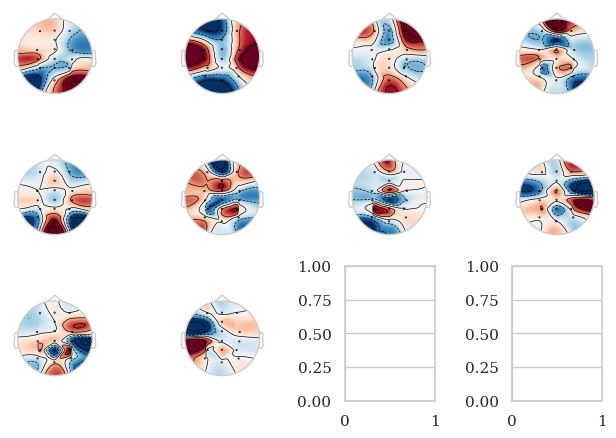

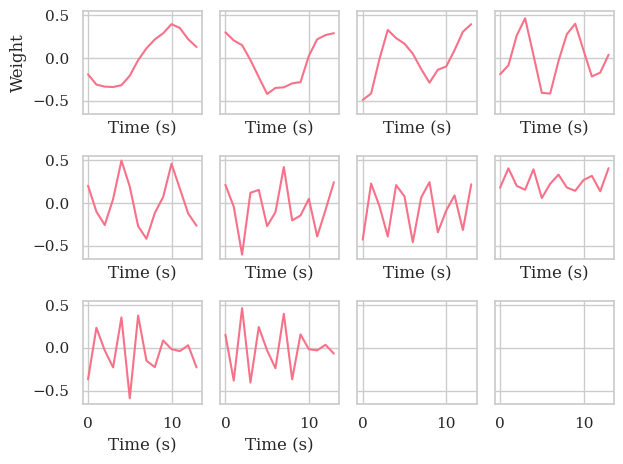

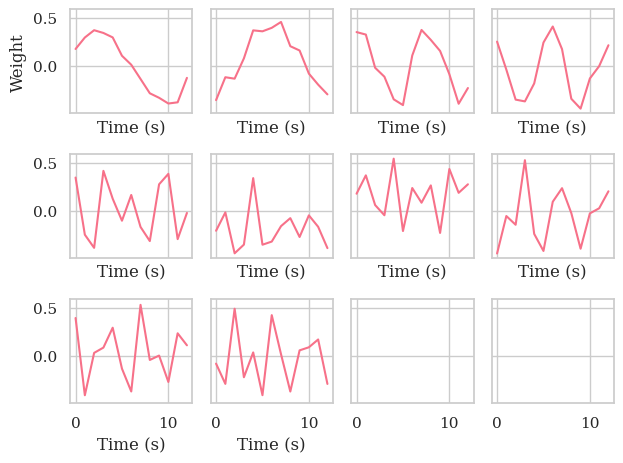

In [12]:
import numpy as np
from mne.viz import plot_topomap
import matplotlib.pyplot as plt
import tensorly as tl

col_wrap = 4

n_col = col_wrap
n_row = int( np.ceil(hoda.rank_(0) / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col, layout='tight')
for i in range(hoda.rank_(0)):
    w = tl.to_numpy(hoda.weights_[0][:,i])
    plot_topomap(w, epochs.info, axes=axs.flatten()[i], show=False)

n_row = int( np.ceil(hoda.rank_(1) / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col,  layout='tight', sharex=True, sharey=True)
for i in range(hoda.rank_(1)):
    w = tl.to_numpy(hoda.weights_[1][:,i])
    axs.flatten()[i].plot(w)
    axs.flatten()[i].set_xlabel('Time (s)')
    axs.flatten()[i].sharey(axs.flatten()[0])
axs.flatten()[0].set_ylabel('Weight');

n_row = int( np.ceil(hoda.rank_(2) / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col,  layout='tight', sharex=True, sharey=True)
for i in range(hoda.rank_(2)):
    w = tl.to_numpy(hoda.weights_[2][:,i])
    axs.flatten()[i].plot(w)
    axs.flatten()[i].set_xlabel('Time (s)')
    axs.flatten()[i].sharey(axs.flatten()[0])
axs.flatten()[0].set_ylabel('Weight');


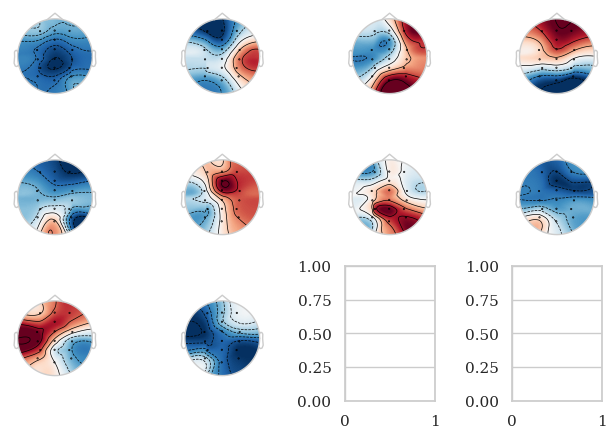

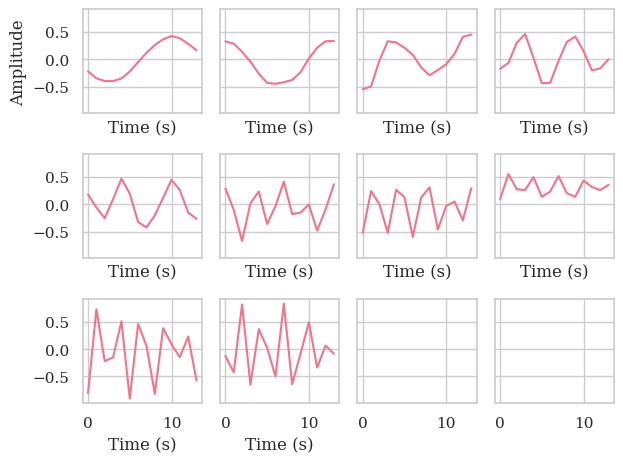

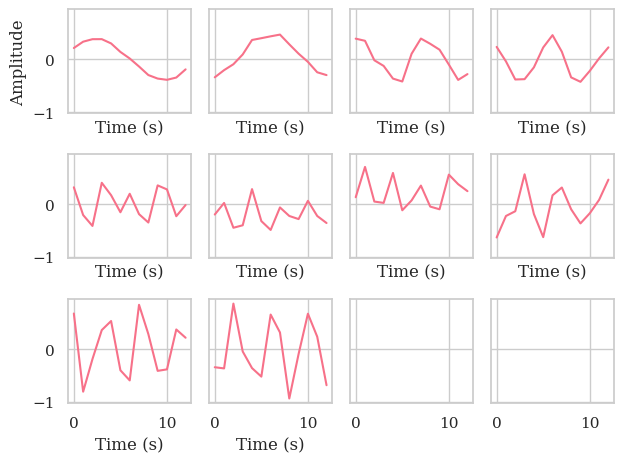

In [13]:
n_row = int(np.ceil(hoda.rank_(0) / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col, layout='tight')
A = hoda.aps_[0]
for i in range(hoda.rank_(0)):
    a = tl.to_numpy(A[:,i])
    plot_topomap(a, epochs.info, axes=axs.flatten()[i], show=False)


n_row = int(np.ceil(hoda.rank_(1) / col_wrap)) 
fig, axs = plt.subplots(
    n_row, n_col, 
    layout='tight', 
    sharex=True,
    sharey=True
)
A = hoda.aps_[1]
for i in range(hoda.rank_(1)):
    a = tl.to_numpy(A[:,i])
    axs.flatten()[i].plot(a)
    axs.flatten()[i].set_xlabel('Time (s)')
    axs.flatten()[i].sharey(axs.flatten()[0])
axs.flatten()[0].set_ylabel('Amplitude')

n_row = int(np.ceil(hoda.rank_(2) / col_wrap)) 
fig, axs = plt.subplots(
    n_row, n_col, 
    layout='tight', 
    sharex=True,
    sharey=True
)
A = hoda.aps_[2]
for i in range(hoda.rank_(2)):
    a = tl.to_numpy(A[:,i])
    axs.flatten()[i].plot(a)
    axs.flatten()[i].set_xlabel('Time (s)')
    axs.flatten()[i].sharey(axs.flatten()[0])
axs.flatten()[0].set_ylabel('Amplitude');

In [15]:
Xt = hoda.transform(X)
Xt

In [17]:
"""
from hoda.hoda import f_oneway
from hoda.gpu_opt import combine_pvalues

import matplotlib
matplotlib.rcParams['axes.linewidth'] = 1
F, p = f_oneway(Xt,y)
"""

"\nfrom hoda.hoda import f_oneway\nfrom hoda.gpu_opt import combine_pvalues\n\nimport matplotlib\nmatplotlib.rcParams['axes.linewidth'] = 1\nF, p = f_oneway(Xt,y)\n"

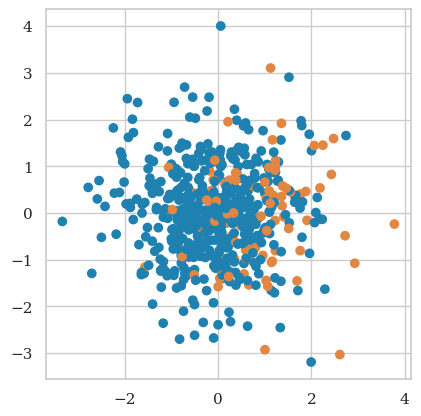

In [18]:

from sklearn.manifold import TSNE
import math
from sklearn.decomposition import PCA
import re, seaborn as sns
import numpy as np
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import ListedColormap

Xt_flat = tl.to_numpy(Xt.reshape((Xt.shape[0], -1)))

if Xt_flat.shape[-1] > 1:
    n_components = 2
    decomp  = PCA(n_components=n_components, whiten=True)
    Xt_viz = decomp.fit_transform(tl.to_numpy(Xt_flat))
    
    cmap = {'Target': '#e28743', 'NonTarget': '#1e81b0'}
    c = np.vectorize(cmap.get)(y)    
    fig, ax = plt.subplots(1,1)
    ax.scatter(Xt_viz[:,0], Xt_viz[:,1], c=c)
    ax.set_aspect('equal')

No projector specified for this dataset. Please consider the method self.add_proj.


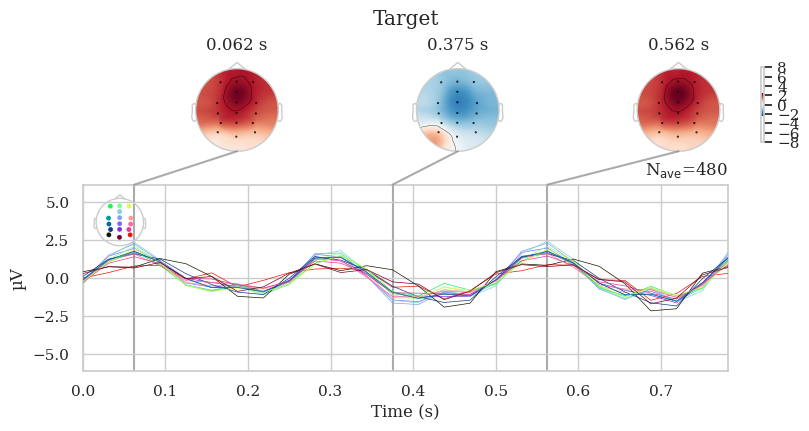

No projector specified for this dataset. Please consider the method self.add_proj.


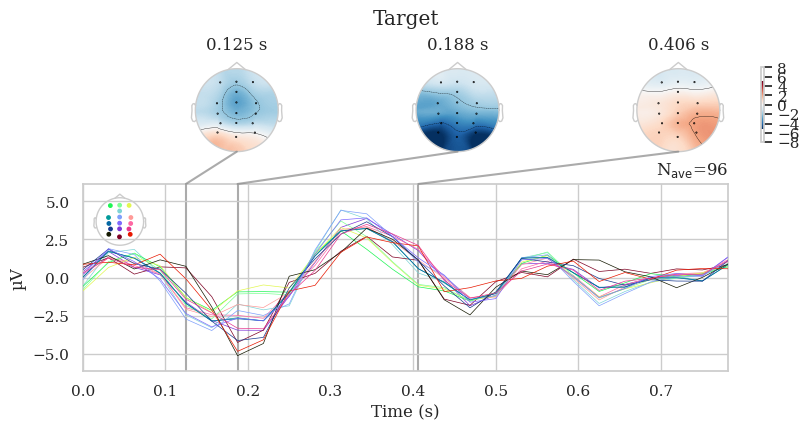

In [19]:
import numpy as np

evokeds = []
vmax=0
for cls in np.unique(labels):
    evoked = epochs[cls].average()
    evokeds.append(evoked)
    vmax= max(vmax, np.max(np.abs(evoked.data))*1.2*1e6)

ts_args=dict(ylim=dict(eeg=[-vmax,vmax]))
joint_args=dict(ts_args=ts_args)

for evoked  in evokeds:
    if len(evoked.ch_names) > 1:
        evoked.plot_joint(title=cls, **joint_args)
    else:
        evoked.plot(**ts_args)

/tmp/ipykernel_3762/1426169175.py:4: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  epochs_rec._data = tl.to_numpy(hankel_tensor_inv(hoda.inv_transform(hoda.transform(hankel_tensor(epochs.get_data())))))


No projector specified for this dataset. Please consider the method self.add_proj.


ValueError: x and y must have same first dimension, but have shapes (26,) and (20,)

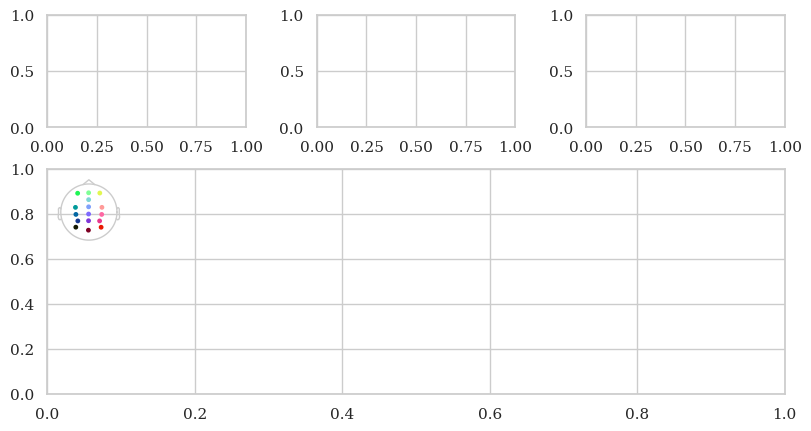

In [20]:
from hoda.tensorize import hankel_tensor, hankel_tensor_inv

epochs_rec = epochs.copy()
epochs_rec._data = tl.to_numpy(hankel_tensor_inv(hoda.inv_transform(hoda.transform(hankel_tensor(epochs.get_data())))))
evokeds_rec = []
for cls in np.unique(labels):
    evoked_rec = epochs_rec[cls].average()
    evokeds_rec.append(evoked_rec)
    if len(evoked_rec.ch_names) > 1:
        _ = evoked_rec.plot_joint(title=cls, **joint_args)
    else:
        _ = evoked_rec.plot(**ts_args)

No projector specified for this dataset. Please consider the method self.add_proj.


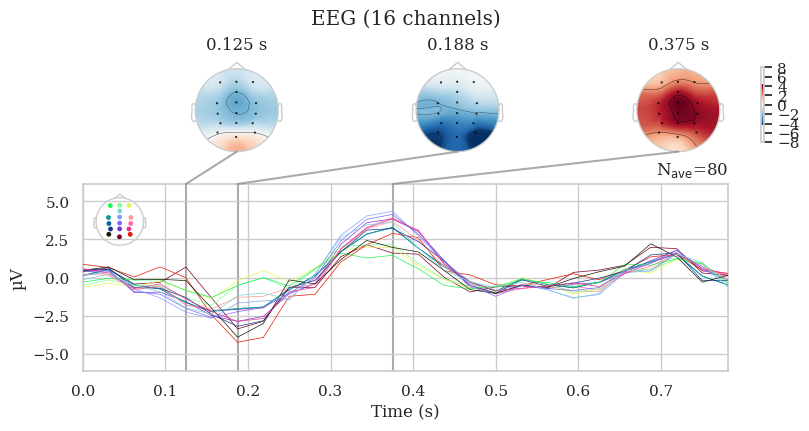

ValueError: weights must be the same size as all_evoked

In [21]:
from mne import combine_evoked
contrast = combine_evoked(evokeds, weights=[-1,1])
_ = contrast.plot_joint(**joint_args)
contrast_rec = combine_evoked(evokeds_rec, weights=[-1,1])
_ = contrast_rec.plot_joint(**joint_args)

In [ ]:
rec_diff = combine_evoked([contrast, contrast_rec], weights=[1,-1])
_ = rec_diff.plot_joint(**joint_args)